# 07 — Global Interpretability
Cross-model feature importance using permutation importance and SHAP.
All three models are compared on the same test set using the same techniques.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np

from src.data import load_data, split_data
from src.models import train_decision_tree, train_knn, train_naive_bayes
from src.interpret_global import permutation_importances, compute_shap_values, plot_shap_summary
from IPython.display import Image

In [2]:
X, y = load_data('../data/heart_failure_clinical_records_dataset.csv')
X_train, X_test, y_train, y_test = split_data(X, y)

FEATURE_NAMES = list(X.columns)

dt  = train_decision_tree(X_train, y_train)
knn = train_knn(X_train, y_train)
nb  = train_naive_bayes(X_train, y_train)

## 1 — Permutation Importance
Shuffle one feature at a time on the test set and measure F1 drop.
Model-agnostic: the same procedure applies to all three models.
Larger drop = feature was more important to that model's predictions.

In [3]:
perm_dt  = permutation_importances(dt,  X_test, y_test, FEATURE_NAMES)
perm_knn = permutation_importances(knn, X_test, y_test, FEATURE_NAMES)
perm_nb  = permutation_importances(nb,  X_test, y_test, FEATURE_NAMES)

# Side-by-side table
perm_table = pd.DataFrame({'feature': FEATURE_NAMES})
perm_table = perm_table.merge(perm_dt[['feature','importance_mean']].rename(columns={'importance_mean':'DT'}), on='feature')
perm_table = perm_table.merge(perm_knn[['feature','importance_mean']].rename(columns={'importance_mean':'KNN'}), on='feature')
perm_table = perm_table.merge(perm_nb[['feature','importance_mean']].rename(columns={'importance_mean':'NB'}), on='feature')
perm_table = perm_table.set_index('feature').round(4)
perm_table

,DT,KNN,NB
feature,,,
age,0.1085,0.0011,0.0325
anaemia,0.0000,0.0029,0.0093
creatinine_phosphokinase,0.0000,0.0120,-0.0055
diabetes,0.0000,0.0173,-0.0088
ejection_fraction,0.0008,0.0180,0.0094
high_blood_pressure,0.0000,0.0287,0.0343
platelets,0.0000,0.0348,0.0110
serum_creatinine,0.0913,0.0410,0.0627
serum_sodium,0.0446,0.0569,0.0185


NameError: name 'perm_dt' is not defined

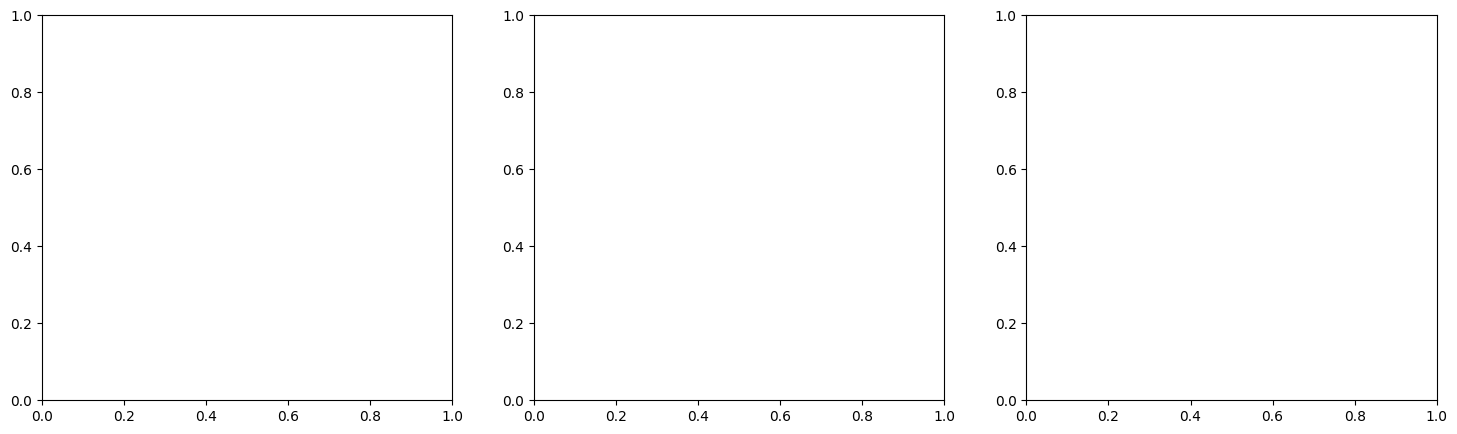

In [1]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, df, title in zip(
    axes,
    [perm_dt, perm_knn, perm_nb],
    ['Decision Tree', 'KNN (k=7)', 'Naive Bayes']
):
    ax.barh(df['feature'][::-1], df['importance_mean'][::-1],
            xerr=df['importance_std'][::-1], color='steelblue', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('F1 drop (mean ± std)')

fig.suptitle('Permutation Importance — All Models', fontsize=13)
fig.tight_layout()
fig.savefig('../outputs/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/permutation_importance.png')

## 2 — SHAP Global Summary
SHAP values quantify each feature's contribution to the model output for every test instance.

- **Decision Tree** → `TreeExplainer` (exact Shapley values)
- **KNN / Naive Bayes** → `KernelExplainer` (model-agnostic approximation, 50 background samples)

All plots show SHAP values for **class 1 (deceased)**.
Each dot is one test instance. Color = raw feature value (red = high, blue = low).
X-axis = SHAP value: positive pushes toward deceased, negative toward survived.

In [2]:
# Decision Tree — TreeExplainer
shap_dt = compute_shap_values(dt, X_train, X_test, model_type='tree')
plot_shap_summary(shap_dt, X_test, FEATURE_NAMES,
                  title='SHAP — Decision Tree (class: deceased)',
                  path='../outputs/shap_dt.png')
Image('../outputs/shap_dt.png')

NameError: name 'compute_shap_values' is not defined

In [3]:
# KNN — KernelExplainer
shap_knn = compute_shap_values(knn, X_train, X_test, model_type='kernel')
plot_shap_summary(shap_knn, X_test, FEATURE_NAMES,
                  title='SHAP — KNN k=7 (class: deceased)',
                  path='../outputs/shap_knn.png')
Image('../outputs/shap_knn.png')

NameError: name 'compute_shap_values' is not defined

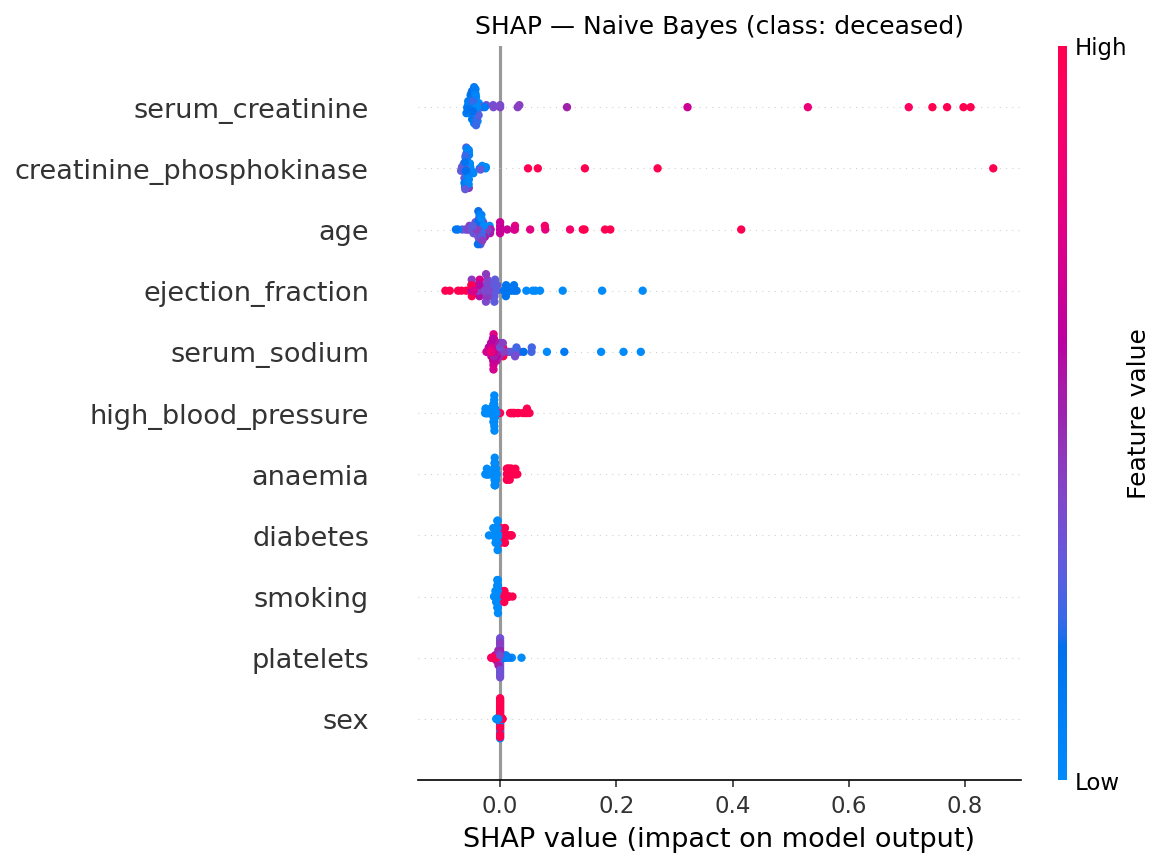

In [7]:
# Naive Bayes — KernelExplainer
shap_nb = compute_shap_values(nb, X_train, X_test, model_type='kernel')
plot_shap_summary(shap_nb, X_test, FEATURE_NAMES,
                  title='SHAP — Naive Bayes (class: deceased)',
                  path='../outputs/shap_nb.png')
Image('../outputs/shap_nb.png')

## 3 — Consolidated Feature Ranking
Raw importance values (permutation F1 drop vs SHAP magnitude) are on different scales
and cannot be compared directly. Instead we rank features within each model and signal,
then report the average rank — lower is more important.

In [8]:
# Build rank table from permutation importance
def rank_df(df, score_col, name):
    df = df.copy()
    df[name] = df[score_col].rank(ascending=False).astype(int)
    return df.set_index('feature')[name]

# Permutation importance ranks
r_perm_dt  = rank_df(perm_dt,  'importance_mean', 'perm_DT')
r_perm_knn = rank_df(perm_knn, 'importance_mean', 'perm_KNN')
r_perm_nb  = rank_df(perm_nb,  'importance_mean', 'perm_NB')

# SHAP mean absolute value ranks
def shap_rank(shap_vals, feature_names, name):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    s = pd.Series(mean_abs, index=feature_names)
    return s.rank(ascending=False).astype(int).rename(name)

r_shap_dt  = shap_rank(shap_dt,  FEATURE_NAMES, 'shap_DT')
r_shap_knn = shap_rank(shap_knn, FEATURE_NAMES, 'shap_KNN')
r_shap_nb  = shap_rank(shap_nb,  FEATURE_NAMES, 'shap_NB')

ranking = pd.concat([r_perm_dt, r_perm_knn, r_perm_nb,
                     r_shap_dt, r_shap_knn, r_shap_nb], axis=1)
ranking['avg_rank'] = ranking.mean(axis=1).round(1)
ranking = ranking.sort_values('avg_rank')
ranking

,perm_DT,perm_KNN,perm_NB,shap_DT,shap_KNN,shap_NB,avg_rank
serum_creatinine,2,2,1,1,3,1,1.7
serum_sodium,3,1,4,5,4,5,3.7
age,1,11,3,3,2,3,3.8
ejection_fraction,4,6,6,2,1,4,3.8
high_blood_pressure,7,5,2,8,5,6,5.5
platelets,7,4,5,8,7,10,6.8
creatinine_phosphokinase,7,8,9,8,9,2,7.2
anaemia,7,10,7,8,6,7,7.5
sex,7,3,8,8,11,11,8.0
diabetes,7,7,10,8,10,8,8.3


## Observations

### Agreement across models
- Features that rank consistently high across all 6 columns are robustly important — the signal is not model-specific.
- Features with high variance in rank are model-dependent — the model's inductive bias determines whether it finds them useful.

### Key divergences to note
- **`serum_creatinine`**: top feature for Decision Tree (root split) and high SHAP for DT, but poorly ranked by Naive Bayes (Gaussian assumption fails on skewed distribution — see Step 5.2).
- **`ejection_fraction`**: consistently important across all three models — the most robust clinical signal in the dataset.
- **Binary features** (`anaemia`, `diabetes`, `sex`, `smoking`, `high_blood_pressure`): generally low-ranked — they carry little marginal predictive value beyond the continuous clinical markers.

### SHAP vs permutation importance
- SHAP measures average contribution to the model output; permutation importance measures the effect on F1 when a feature is destroyed.
- They should largely agree — large disagreements indicate features that are correlated with others (shuffling one doesn't hurt much if another carries the same information).

### TreeExplainer vs KernelExplainer
- DT SHAP values are exact; KNN and NB SHAP values are approximations (100 samples per instance).
- Rankings are comparable but absolute magnitudes are not.